# Matching and Tests

When you add an experiment to the database, `odyn` matches olfactometer trials to acquisitions, and a series of tests is run. 

This notebook gives a brief overview of the matching algorithm and the possible errors you can get adding an experiment.

## Matching Algorithm

The matching happens in two steps:
- Acquisitions get matched to trial starts in the H5 file;
- H5 trials get matched to olfactometer trials.

To further break the first step down:
- It finds trial starts, odor window starts, and odor window ends (failing if there is a mismatch);
- It assumes the first trial in the H5 starts at the same time as the loop start;
- H5 trial starts match to the first acquisition that is within tolerance (100ms).

This first step works even when there are missing TIFFs, because it only takes timing into account.

For the second step, we assume that olfactometer trials match exactly to H5 trial starts, possibly with some misses in the beginning or in the end (on the H5 side). Thus, we just test all possible pairings and pick the one with the smallest overall timing difference (using the standard deviation).

As an example, assume there are 6 olfactometer trials but only 4 H5 trial starts. Then, we test these 3 possible pairings:
```
Olfactometer    #  #  #  #  #  #    or    #  #  #  #  #  #    or    #  #  #  #  #  #
H5 trials       #  #  #  #                   #  #  #  #                   #  #  #  #
```
and we pick whatever matching has the smallest standard deviation for the timing difference.

## Possible Errors and Flags

The possible flags for `add_experiment` are:
- 0 = Success;
- 1 = Other errors;
- 2 = Already in the DB;
- 4 = More than one H5 file;
- 8 = TIFFs without the expected metadata;
- 16 = Multiple loop starts in the folder;
- 32 = H5 trials without acquisition;
- 64 = Olfactometer trials without acquisition;

Flags below 32 are failures, _i.e._ the experiment is not added to the DB, but 32 and 64 are only warnings.

Below we show how to check the flags in the DB. 

In [1]:
from odyn import Database, Group

db = Database(r"tmp\test_server")

[INFO] Import Database and Group classes for db UI and help functions!
[INFO] You can use 'from odyn import Database, Group' to import them.
[INFO] Hovering over 'Database' and 'Group' will give you some tips.
[INFO] Connected to the database at: 'C:\Users\ambrosiv\Projects\ODyn\tmp\test_server\.odyn\odyn.db'


In [ ]:
# add_experiments where something was reported (latest first)
calls = db.latest_calls("add_experiment")
calls[calls.call_flag > 0]

,group_id,called_at,method_name,git_commit,call_log,call_flag,rel_path,rel_raw_paths
method_call_id,,,,,,,,
868,0,2026-07-14 19:08:22,Database.add_experiment,bd2649c5684efacc2f9f5ad3f91bacc6a13b8be5,[INFO] Recorded method call to db (method_call...,4,20260714/m472/e1,[20260714/m472/e1/raw/20260714_m472_e1_00001.t...
867,0,2026-07-14 19:08:21,Database.add_experiment,bd2649c5684efacc2f9f5ad3f91bacc6a13b8be5,[INFO] Recorded method call to db (method_call...,4,20260714/m465/e1,[20260714/m465/e1/raw/20260714_m465_e1_00001.t...
866,0,2026-07-14 19:08:20,Database.add_experiment,bd2649c5684efacc2f9f5ad3f91bacc6a13b8be5,[INFO] Recorded method call to db (method_call...,4,20260714/m462/e1,[20260714/m462/e1/raw/20260714_m462_e1_00001.t...
865,0,2026-07-14 19:08:19,Database.add_experiment,bd2649c5684efacc2f9f5ad3f91bacc6a13b8be5,[INFO] Recorded method call to db (method_call...,4,20260713/m472/e1,[20260713/m472/e1/raw/20260713_m472_e1_00001.t...
864,0,2026-07-14 19:08:19,Database.add_experiment,bd2649c5684efacc2f9f5ad3f91bacc6a13b8be5,[INFO] Recorded method call to db (method_call...,4,20260713/m462/e1,[20260713/m462/e1/raw/2026_07_13_m462_e1_00001...
...,...,...,...,...,...,...,...,...
29,0,2026-07-09 17:03:51,Database.add_experiment,35875c29bb996ea4b3b75242f0d09ee9bed4792d,[INFO] Recorded method call to db (method_call...,96,20250624\M55\e1,"[20250624\M55\e1\raw\20250624_m0055_00001.tif,..."
21,0,2026-07-09 17:01:50,Database.add_experiment,35875c29bb996ea4b3b75242f0d09ee9bed4792d,[INFO] Recorded method call to db (method_call...,16,20250409,"[20250409\raw\20250409_slicetest__00001.tif, 2..."
18,0,2026-07-09 17:01:44,Database.add_experiment,35875c29bb996ea4b3b75242f0d09ee9bed4792d,[INFO] Recorded method call to db (method_call...,1,20250321\e2,"[20250321\e2\raw\20250321_m0043_00063.tif, 202..."


In [ ]:
# Showing a particular call log
# You have to `print` to show it properly
print(calls.loc[42, "call_log"])

[INFO] Recorded method call to db (method_call_id = 42).
[INFO] Adding experiment to database...
[INFO] Processing folder: '\\rdsmsb.ohsu.edu\MossLab\ImagingData\20250707\M55\e1'
[INFO] Getting timing data from: 'M:\ImagingData\20250707\M55\e1\20250707_M0055_00001.h5'
[INFO] Found 130 trial starts in the H5 file.
[INFO] Found 6 olfactometer event files.
[INFO] Passed all TIFF metadata checks! ✔
[INFO] Average clock offset (event - h5): 1026.8 ms, std: 15.5 ms
[WARNING] 4 H5 trials without matching acquisition. ✘
[WARNING] 4 trials matched to H5 but no acquisition. ✘



## Timing Differences

<Axes: ylabel='Frequency'>

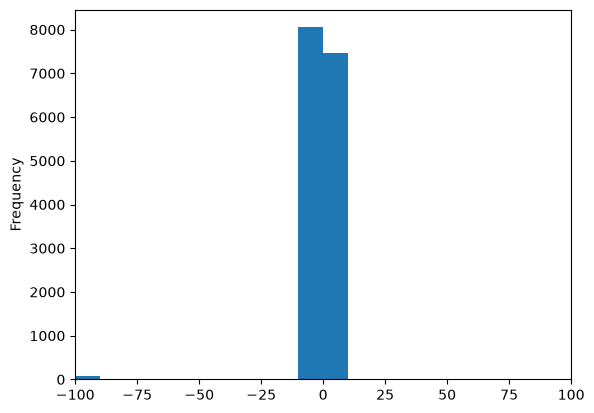

In [14]:
# Timing differences between H5 trial starts and the corresponding acquisition
db.acquisitions.h5_to_acq_ms.plot(kind="hist", xlim=(-100,100), bins=range(-100,100,10))

<Axes: ylabel='Frequency'>

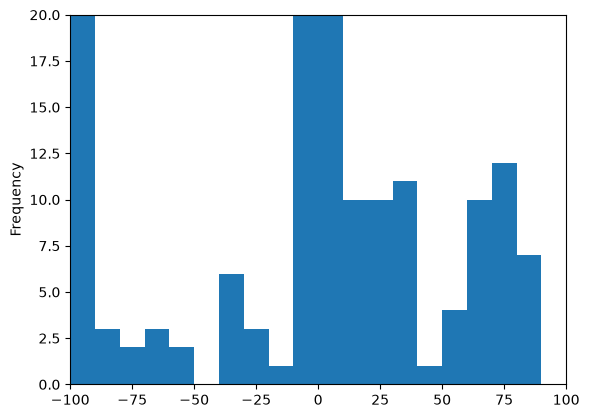

In [15]:
# Smaller y scale to see the outliers
db.acquisitions.h5_to_acq_ms.plot(kind="hist", xlim=(-100,100), ylim=(0, 20), bins=range(-100,100,10))

In [5]:
# Convert timing difference to seconds
df = db.trials
df["time_diff_s"] = df.h5_to_trial_ms / 1000
df["time_diff_s"] = df.h5_to_trial_ms / 1000

<Axes: ylabel='Frequency'>

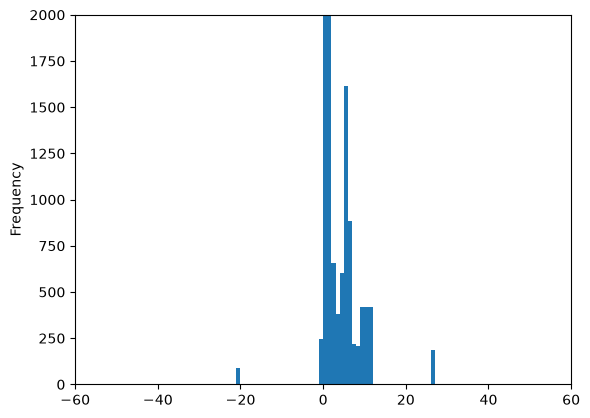

In [6]:
# Timing difference between olfactometer trials and H5 trial starts
df.time_diff_s.plot(kind="hist", xlim=(-60,60), ylim=(0,2000), bins=range(-60,60,1))

<Axes: ylabel='Frequency'>

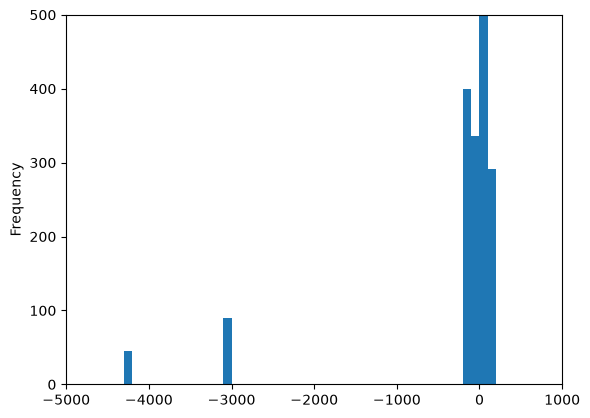

In [ ]:
# Smaller y scale to see the outliers
df.time_diff_s.plot(kind="hist", xlim=(-5000,1000), ylim=(0,500), bins=range(-5000,1000,100))